In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory


In [2]:
path = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix


In [4]:
def crop_brain_contour(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)

    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = cnts[0] if len(cnts) == 2 else cnts[1]
    
    if len(cnts) == 0:
        return image  
        
    c = max(cnts, key=cv2.contourArea)

    extLeft = tuple(c[c[:, :, 0].argmin()][0])
    extRight = tuple(c[c[:, :, 0].argmax()][0])
    extTop = tuple(c[c[:, :, 1].argmin()][0])
    extBot = tuple(c[c[:, :, 1].argmax()][0])

    # Crop image based on points
    new_image = image[extTop[1]:extBot[1], extLeft[0]:extRight[0]]
    return new_image

In [5]:
IMG_SIZE = 224
LABELS = ['glioma', 'meningioma', 'notumor', 'pituitary']

def load_data(data_dir):
    images = []
    labels = []

    for label in LABELS:
        folder_path = os.path.join(data_dir, label)
        if not os.path.exists(folder_path):
            folder_path = os.path.join(data_dir, label.capitalize())

        for img_name in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_name)

            # Read the photo
            image = cv2.imread(img_path)
            if image is None:
                continue
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
          
            cropped_img = crop_brain_contour(image)
            resized_img = cv2.resize(cropped_img, (IMG_SIZE, IMG_SIZE))

            images.append(resized_img)
            labels.append(LABELS.index(label))

    return np.array(images, dtype='float32'), np.array(labels)

train_dir = os.path.join(path, 'Training')
test_dir = os.path.join(path, 'Testing')

X_train, y_train = load_data(train_dir)
X_test, y_test = load_data(test_dir)

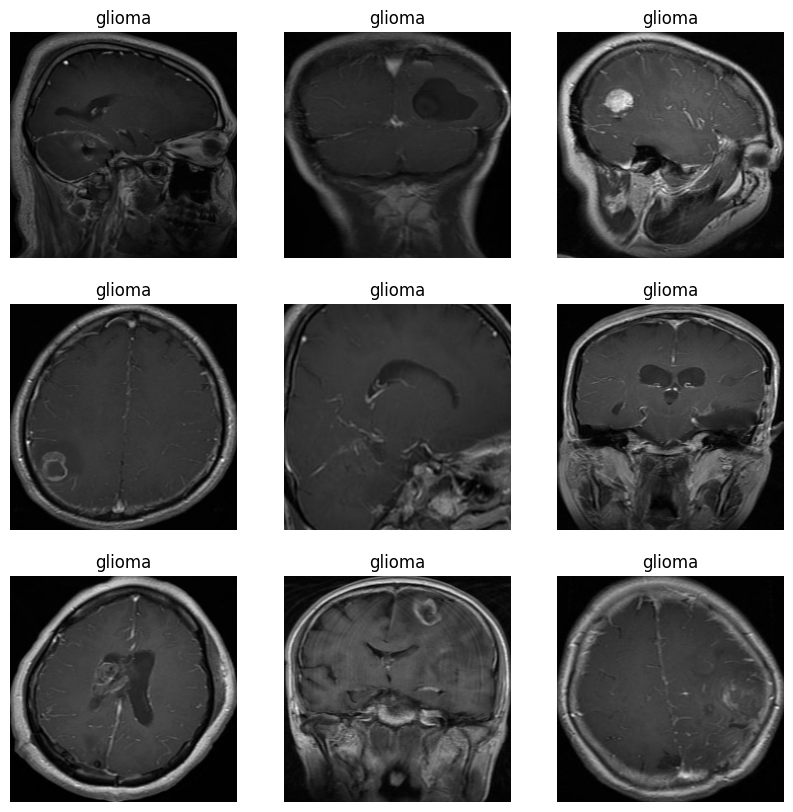

In [6]:
def plot_sample_images(X, y):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(X[i].astype('uint8'))
        plt.title(LABELS[y[i]])
        plt.axis('off')
    plt.show()

plot_sample_images(X_train, y_train)

In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")


def build_brain_tumor_model(input_shape=(224, 224, 3), num_classes=4):

    inputs = layers.Input(shape=input_shape)

    x = data_augmentation(inputs)

    efficientnet_base = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )

    efficientnet_base.trainable = False

    x = efficientnet_base(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        name="predictions"
    )(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="Brain_Tumor_Classifier"
    )

    return model, efficientnet_base


model, efficientnet_base_model = build_brain_tumor_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        "best_brain_tumor_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

model.summary()


I0000 00:00:1788639065.810246      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "Brain_Tumor_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,059,815 (15.49 MB)

 Trainable params: 7,684 (30.02 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [8]:
history = model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=10,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/10


E0000 00:00:1788639084.477950      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/Brain_Tumor_Classifier_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5434 - loss: 1.2918
Epoch 1: val_loss improved from None to 0.59598, saving model to best_brain_tumor_model.keras

Epoch 1: finished saving model to best_brain_tumor_model.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 30s 103ms/step - accuracy: 0.6590 - loss: 0.9510 - val_accuracy: 0.7762 - val_loss: 0.5960 - learning_rate: 0.0010
Epoch 2/10
148/149 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7612 - loss: 0.6374
Epoch 2: val_loss improved from 0.59598 to 0.18897, saving model to best_brain_tumor_model.keras

Epoch 2: finished saving model to best_brain_tumor_model.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.7691 - loss: 0.6195 - val_accuracy: 0.9536 - val_loss: 0.1890 - learning_rate: 0.0010
Epoch 3/10
148/149 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7882 - loss: 0.5573
Epoch 3: val_loss improved from 0.18897 to 0.13035, saving model to best_brain_tumor_model.keras

Epoch 3: finished saving model to best_brain_t

In [9]:
base_model = model.get_layer('efficientnetb0')
base_model.trainable = True

for layer in base_model.layers[:-30]:  
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # 10^-5 معدل تعلم منخفض جداً
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=15, 
    batch_size=16, 
    callbacks=callbacks 
)

Epoch 1/15


E0000 00:00:1788639214.507391      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/Brain_Tumor_Classifier_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


297/298 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7207 - loss: 0.7105
Epoch 1: val_loss did not improve from 0.07791
298/298 ━━━━━━━━━━━━━━━━━━━━ 32s 61ms/step - accuracy: 0.7267 - loss: 0.7067 - val_accuracy: 0.9131 - val_loss: 0.2626 - learning_rate: 1.0000e-05
Epoch 2/15
297/298 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7533 - loss: 0.6409
Epoch 2: val_loss did not improve from 0.07791
298/298 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.7651 - loss: 0.6147 - val_accuracy: 0.9369 - val_loss: 0.2268 - learning_rate: 1.0000e-05
Epoch 3/15
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7884 - loss: 0.5766
Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.

Epoch 3: val_loss did not improve from 0.07791
298/298 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.7807 - loss: 0.5954 - val_accuracy: 0.9464 - val_loss: 0.1786 - learning_rate: 1.0000e-05
Epoch 4/15
297/298 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8059 - loss: 0.5263
Epo

In [10]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.8213 - loss: 0.5317

Test Accuracy: 82.13%


50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step
Classification Report - Brain Tumor Detection
              precision    recall  f1-score   support

      glioma       0.84      0.65      0.73       400
  meningioma       0.72      0.70      0.71       400
     notumor       0.91      0.97      0.94       400
   pituitary       0.81      0.95      0.88       400

    accuracy                           0.82      1600
   macro avg       0.82      0.82      0.82      1600
weighted avg       0.82      0.82      0.82      1600



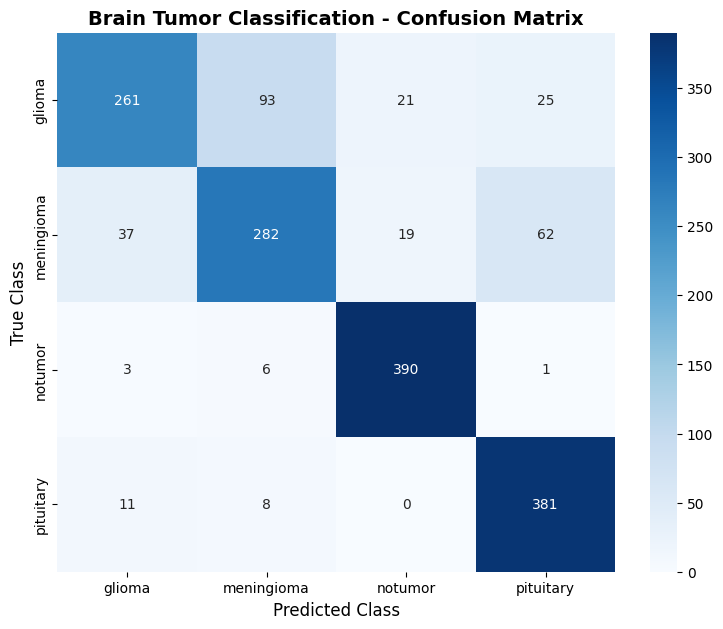

In [11]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("=" * 60)
print("Classification Report - Brain Tumor Detection")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=LABELS))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=LABELS, yticklabels=LABELS)
plt.title('Brain Tumor Classification - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.show()

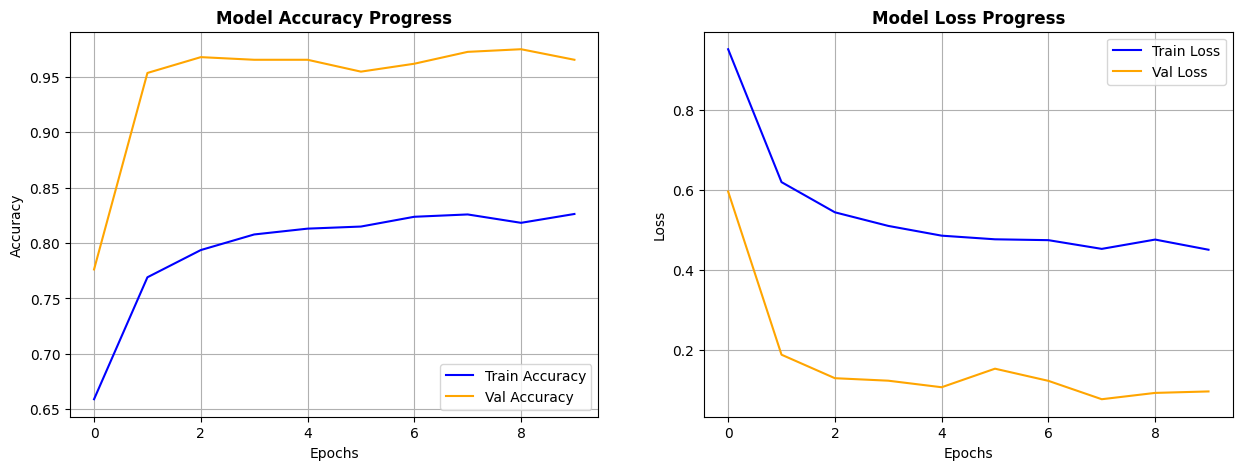

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
ax[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
ax[0].set_title('Model Accuracy Progress', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(history.history['loss'], label='Train Loss', color='blue')
ax[1].plot(history.history['val_loss'], label='Val Loss', color='orange')
ax[1].set_title('Model Loss Progress', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend()
ax[1].grid(True)

plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_8']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


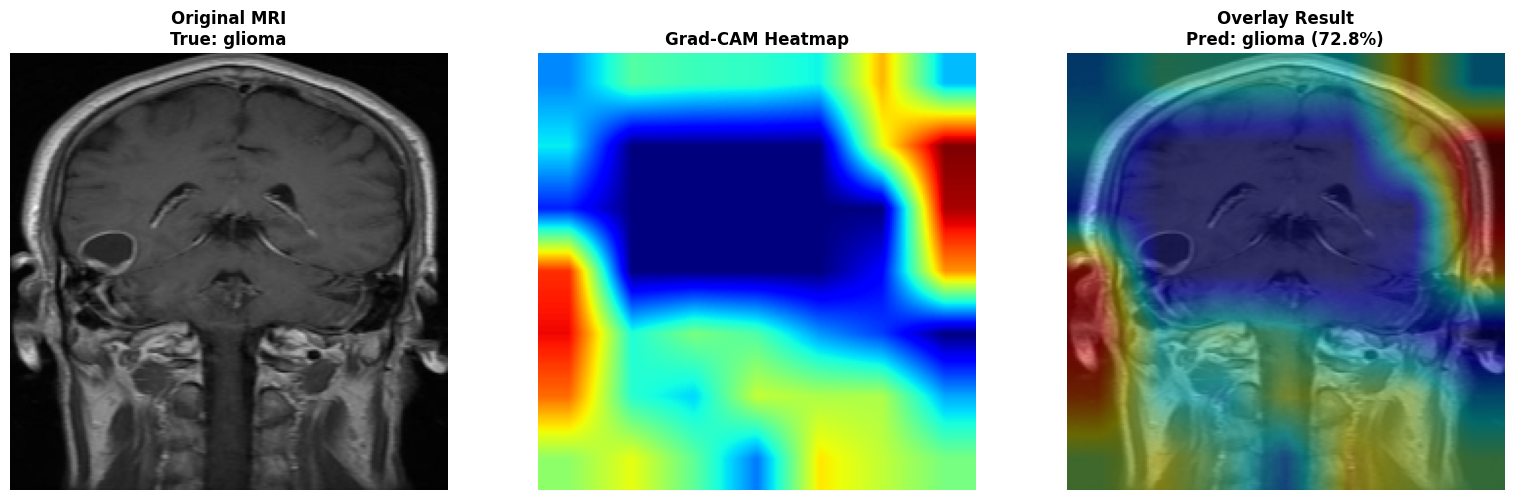

In [13]:
def make_gradcam_heatmap(img_array, model, pred_index=None):
    # 1. Define the Base Model (EfficientNet) layer and the final classification layer
    base_model = None
    for layer in model.layers:
        if 'efficientnet' in layer.name.lower():
            base_model = layer
            break

    # Extract the last Conv layer inside EfficientNet (default name top_conv)
    if base_model is not None:
        last_conv_layer = base_model.get_layer('top_conv')
        feature_extractor = tf.keras.models.Model(
            inputs=base_model.inputs, 
            outputs=last_conv_layer.output
        )
    else:
        # If the model is flat without Nested Base
        last_conv_layer = model.get_layer('top_conv')
        feature_extractor = tf.keras.models.Model(
            inputs=model.inputs, 
            outputs=last_conv_layer.output
        )

    # 2. Build a submodel for the Classifier Head after the Base Model
    classifier_inputs = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_inputs
    
    # Connect the rest of the classification layers (GlobalAveragePooling, Dropout, Dense)
    start_collecting = False
    for layer in model.layers:
        if layer == base_model:
            start_collecting = True
            continue
        if start_collecting:
            x = layer(x)
            
    classifier_model = tf.keras.models.Model(classifier_inputs, x)

    # 3. Calculating Gradients Using GradientTape    with tf.GradientTape() as tape:
        last_conv_layer_output = feature_extractor(img_array)
        tape.watch(last_conv_layer_output)
        preds = classifier_model(last_conv_layer_output)
        
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Extract gradients and increase Heatmap variance
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Clean up وتطبيع القيم بين 0 و 1
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()


def display_gradcam_sample(image_index, X_data, y_true, model, labels_list):
    img = X_data[image_index]
    img_array = np.expand_dims(img, axis=0)
    
     # prediction
    
    preds = model.predict(img_array, verbose=0)
    pred_class_idx = np.argmax(preds[0])
    pred_label = labels_list[pred_class_idx]
    true_label = labels_list[y_true[image_index]]
    confidence = preds[0][pred_class_idx] * 100

    heatmap = make_gradcam_heatmap(img_array, model)

    # Enlarge the original Heatmap size
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_colored = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # Merge image with Heatmap
    superimposed_img = cv2.addWeighted(img.astype('uint8'), 0.6, heatmap_colored, 0.4, 0)

    # Drawing the three shapes
    fig, ax = plt.subplots(1, 3, figsize=(16, 5))
    
    ax[0].imshow(img.astype('uint8'))
    ax[0].set_title(f"Original MRI\nTrue: {true_label}", fontsize=12, fontweight='bold')
    ax[0].axis('off')

    ax[1].imshow(heatmap_resized, cmap='jet')
    ax[1].set_title("Grad-CAM Heatmap", fontsize=12, fontweight='bold')
    ax[1].axis('off')

    ax[2].imshow(superimposed_img)
    ax[2].set_title(f"Overlay Result\nPred: {pred_label} ({confidence:.1f}%)", fontsize=12, fontweight='bold')
    ax[2].axis('off')

    plt.tight_layout()
    plt.show()

display_gradcam_sample(10, X_test, y_test, model, LABELS)

In [14]:
!pip install -q "gradio>=5,<6"

In [ ]:
import gradio as gr

def predict_and_explain(input_image):

    if input_image is None:
        return None, {
            "No Image": 1.0
        }

    try:

        # 1. Preprocessing

        cropped_img = crop_brain_contour(input_image)

        if cropped_img is None or cropped_img.size == 0:
            cropped_img = input_image

        resized_img = cv2.resize(
            cropped_img,
            (IMG_SIZE, IMG_SIZE)
        )

         img_array = np.expand_dims(
            resized_img,
            axis=0
        ).astype("float32")

        # 2. Prediction

        preds = model(
            img_array,
            training=False
        ).numpy()[0]

        pred_idx = int(np.argmax(preds))
        pred_label = LABELS[pred_idx]

        # 3. Confidence scores

        confidences = {
            LABELS[i]: float(preds[i])
            for i in range(len(LABELS))
        }

        # 4. Grad-CAM

        heatmap = make_gradcam_heatmap(
            img_array,
            model,
            pred_index=pred_idx
        )

        heatmap_resized = cv2.resize(
            heatmap,
            (IMG_SIZE, IMG_SIZE)
        )

        heatmap_uint8 = np.uint8(
            255 * heatmap_resized
        )

        heatmap_colored = cv2.applyColorMap(
            heatmap_uint8,
            cv2.COLORMAP_JET
        )

        heatmap_colored = cv2.cvtColor(
            heatmap_colored,
            cv2.COLOR_BGR2RGB
        )

        # 5. Overlay
       
        overlay_img = cv2.addWeighted(
            resized_img.astype("uint8"),
            0.6,
            heatmap_colored,
            0.4,
            0
        )

        return overlay_img, confidences


    except Exception as e:

        print("Prediction Error:", repr(e))

        return (
            resized_img.astype("uint8"),
            {
                "Error": 1.0
            }
        )

# Gradio Interface

interface = gr.Interface(

    fn=predict_and_explain,

    inputs=gr.Image(
        type="numpy",
        label="Upload Brain MRI Scan"
    ),

    outputs=[
        gr.Image(
            type="numpy",
            label="Grad-CAM Tumor Localization"
        ),

        gr.Label(
            num_top_classes=4,
            label="Classification Probabilities"
        )
    ],

    title="Brain Tumor Detection & Explainable AI (XAI)",

    description=(
        "Brain tumor classification from MRI scans "
        "using EfficientNetB0 with Grad-CAM "
        "tumor localization."
    ),

    examples=[]
)


interface.launch(
    share=True,
    debug=True,
    show_error=True
)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://efd5418a2d85d9f3d3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_8']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_8']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
